# Predicting duration of delivery

The objective of the machine learning section was to identify factors influencing delivery duration and evaluate predictive model performance.

## 0. Libraries and data

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('delivery_clean.csv')
data

,date,weekday,hour,time_start,time_end,duration_minutes,temp,fall,wind,bad_weather_flag,basic,factor,tip,total,type,target,tar_sym,is_weekend
0,2025-12-02,Tuesday,9,09:04:00,09:46:00,42,1.0,0.0,1.0,False,18.05,1.69,0.00,18.05,breakfast,Stare Miasto,I,False
1,2025-12-02,Tuesday,9,09:46:00,10:19:00,33,1.0,0.0,1.8,False,12.19,1.69,0.00,12.19,breakfast,Podgórze,XIII,False
2,2025-12-02,Tuesday,10,10:20:00,11:04:00,44,1.5,0.0,0.9,False,14.34,1.52,0.00,14.34,coffee,Krowodrza,V,False
3,2025-12-02,Tuesday,11,11:50:00,12:17:00,27,2.0,0.0,1.7,False,11.55,1.67,2.25,13.80,vietnamese,Prądnik Biały,IV,False
4,2025-12-02,Tuesday,12,12:17:00,13:02:00,45,2.5,0.0,1.2,False,17.53,1.97,0.00,17.53,groceries,Bronowice,VI,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
446,2026-04-29,Wednesday,10,10:03:00,10:43:00,40,9.9,0.0,1.5,False,10.39,1.76,0.00,10.39,coffee,Grzegórzki,II,False
447,2026-04-29,Wednesday,10,10:43:00,11:17:00,34,10.8,0.0,1.7,False,8.07,1.76,0.00,8.07,fast food,Podgórze,XIII,False
448,2026-04-29,Wednesday,12,12:59:00,13:24:00,25,11.8,0.0,1.8,False,11.17,2.32,0.00,11.17,fast food,Prądnik Czerwony,III,False
449,2026-04-29,Wednesday,13,13:24:00,13:48:00,24,12.0,0.0,3.6,False,11.78,2.34,0.00,11.78,fast food,Prądnik Czerwony,III,False


In [ ]:
data['date'] = pd.to_datetime(data['date'] + ' ' + data['time_start'])
data["hour"] = data["date"].dt.hour

data["hour"] = data["date"].dt.hour
hourly_orders = (
    data.groupby("hour")
      .size())

## 1. Define target

In [ ]:
target = "duration_minutes"

## 2. Select features

In [ ]:
features = [
    "hour",
    "temp",
    "wind",
    "fall",
    "factor",
    "is_weekend",
    "target",
    "type"
]

In [ ]:
numeric_features = [
    "hour",
    "temp",
    "wind",
    "fall",
    "factor"
]

In [ ]:
categorical_features = [
    "target",
    "type",
    "is_weekend"
]

## 3. Train/test split

In [ ]:
X = data[features]
y = data[target]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 4. Preprocessing

In [ ]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [ ]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# 5. Baseline model- linear regression

In [ ]:
lr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [ ]:
lr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['hour', 'temp', 'wind',
                                                   'fall', 'factor']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['target', 'type',
                                                   'is_weekend'])])),
                ('model', LinearRegression())])

In [ ]:
y_pred = lr_model.predict(X_test)

Evaluation

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 7.6142690713652055
RMSE: 9.940332360508283
R2: -0.08026864918627541


# 6. Better model- random forest

In [ ]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42
        ))
    ]
)

In [ ]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['hour', 'temp', 'wind',
                                                   'fall', 'factor']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['target', 'type',
                                                   'is_weekend'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [ ]:
rf_pred = rf_model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, rf_pred)
rmse = mean_squared_error(y_test, rf_pred) ** 0.5
r2 = r2_score(y_test, rf_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

# 7. Evaluation

The Random Forest model achieved better predictive performance than the baseline model, reducing the average prediction error to approximately 7 minutes. However, the relatively low R² score indicates that delivery duration is influenced by additional external factors not captured in the dataset, such as traffic conditions or restaurant preparation time.

# 8. Feature importance

In [ ]:
model = rf_model.named_steps["model"]

importance = model.feature_importances_

In [ ]:
encoded_features = (
    rf_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

In [ ]:
importance_df = pd.DataFrame({
    "feature": encoded_features,
    "importance": importance
})

In [ ]:
importance_df = (
    importance_df
    .sort_values(
        by="importance",
        ascending=False
    )
)
#importance_df.to_csv("feature_importance.csv")

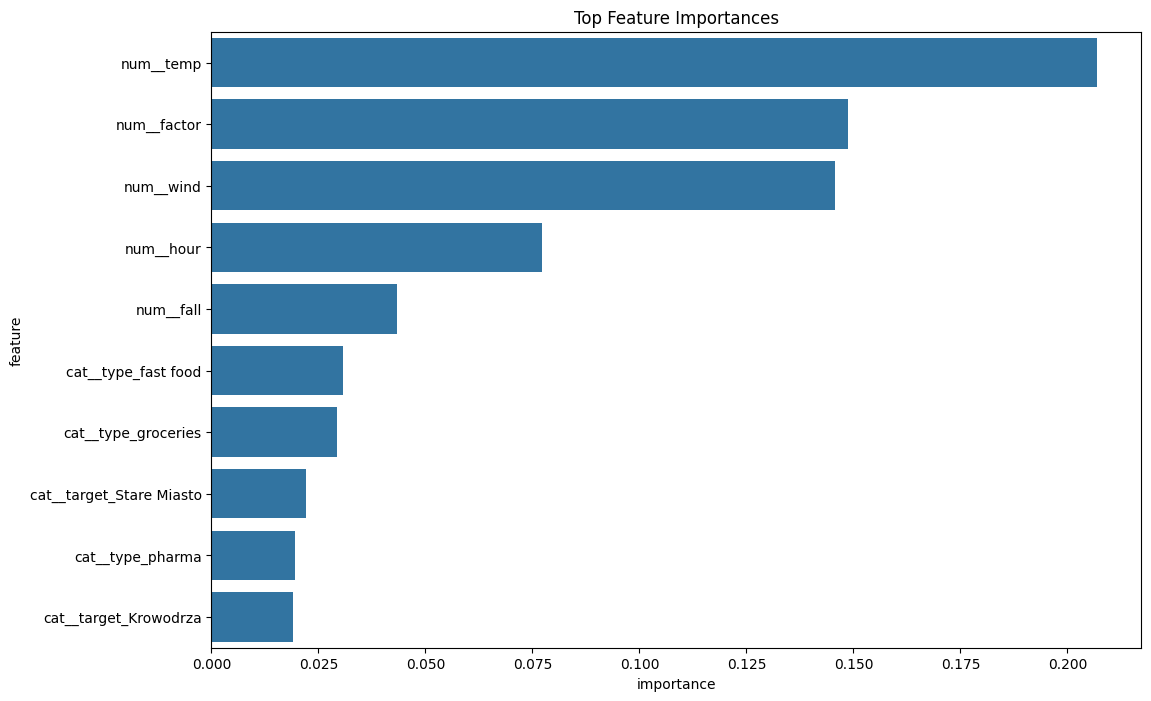

In [ ]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=importance_df.head(10),
    x="importance",
    y="feature"
)

plt.title("Top Feature Importances")

plt.show()

The most influential features in predicting delivery duration were temperature, wind speed, and multiplier factor.

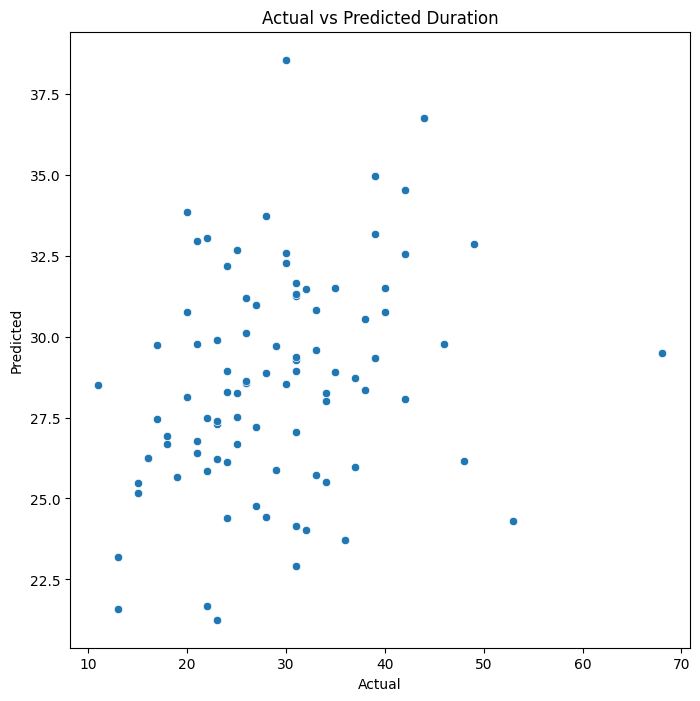

In [ ]:
plt.figure(figsize=(8,8))

sns.scatterplot(
    x=y_test,
    y=rf_pred
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted Duration")


plt.show()

In [ ]:
results = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred
})

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="neg_mean_absolute_error"
)

cross_value = pd.DataFrame({
    "CVS": [scores.mean()]
})

cross_value.to_csv("cvs.csv")

print(scores.mean())

Cross-validation confirmed stable model performance with an average MAE of approximately 8 minutes across folds.

In [ ]:
results["residuals"] = (
    results["actual"] - results["predicted"]
)

# 9. Conclusions

The Random Forest model outperformed the baseline linear regression model, reducing average prediction error to approximately 7 minutes.
Cross-validation confirmed stable model performance across different train-test splits.
However, the relatively low R² score suggests that delivery duration depends on additional external factors not included in the dataset.